# Optimización de Inversiones y Análisis de Riesgo en Exploración Petrolera (OilyGiant)

### Introduccion

En el sector de extracción de hidrocarburos, la decisión de dónde perforar nuevos pozos conlleva inversiones de capital masivas y un alto grado de incertidumbre geológica. El presente proyecto se desarrolla para la compañía de extracción OilyGiant, con el objetivo estratégico de identificar la región más rentable y segura para la apertura de 200 nuevos pozos petrolíferos, respaldando la toma de decisiones mediante modelos predictivos y análisis estadístico robusto.

A partir de un presupuesto operativo de 100 millones de dólares y datos de exploración geológica correspondientes a tres regiones distintas, el reto principal trasciende la simple predicción del volumen de reservas de crudo; exige cuantificar la rentabilidad esperada y mitigar el riesgo financiero asociado a cada zona geográfica.

Para transformar estos datos en inteligencia de negocio accionable, el proyecto se estructura en las siguientes fases metodológicas:

* **Modelado Predictivo:** Entrenamiento y validación de modelos de Regresión Lineal para pronosticar el volumen de reservas de crudo en pozos individuales, basándose en sus características geológicas.
  

* **Estimación de Rentabilidad:** Selección de los 200 yacimientos con mayor potencial proyectado en cada región para calcular el margen de beneficio esperado, estableciendo el punto de equilibrio operativo.

* **Evaluación de Riesgos:** Aplicación de la técnica de Bootstrapping (*simulando 1,000 escenarios de extracción*) para modelar la distribución de las ganancias, definir intervalos de confianza del 95% y evaluar la probabilidad de pérdidas.

**El criterio de negocio es estricto:** solo se considerarán viables aquellas regiones cuyo riesgo de pérdida financiera sea inferior al *2.5%*. A través de este enfoque analítico integral, se busca maximizar la eficiencia en la asignación de recursos y asegurar el mayor retorno de inversión posible para la compañía.

## 1. Descarga , EDA y Preparación de Datos

Primero importaremos las librerías necesarias, cargaremos los datos, haremos el analisis exploratorio inicial de datos (EDA) y preparacion de datos:

In [1]:
# 1. Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Configuración visual para seaborn
sns.set_theme(style="whitegrid")

# 2. Cargamos las base de datos
df0 = pd.read_csv('/datasets/geo_data_0.csv')
df1 = pd.read_csv('/datasets/geo_data_1.csv')
df2 = pd.read_csv('/datasets/geo_data_2.csv')


# 3. Exploracion de datos (EDA)
def explorar_datos(df, nombre_region):
    print(f"\n{'='*50}")
    print(f"--- REPORTE DE EXPLORACIÓN: {nombre_region} ---")
    print(f"{'='*50}\n")
    
    print("1. Primeras 5 filas del dataset:")
    display(df.head()) # 'display' muestra tablas con formato bonito en Jupyter
    
    print("\n2. Información general y tipos de datos:")
    df.info()
    
    print("\n3. Estadísticas descriptivas:")
    display(df.describe())
    
    print("\n4. Conteo de valores nulos:")
    print(df.isnull().sum())
    
    print(f"\n5. Filas idénticas duplicadas: {df.duplicated().sum()}")
    print(f"6. IDs duplicados (mediciones repetidas): {df['id'].duplicated().sum()}")


# Ejecutar la función de exploración para cada DataFrame
explorar_datos(df0, "Región 0 (geo_data_0.csv)")
explorar_datos(df1, "Región 1 (geo_data_1.csv)")
explorar_datos(df2, "Región 2 (geo_data_2.csv)")


# 4. Preparacion de datos
def preparar_datos(df):
    # Eliminamos la columna 'id' porque no aporta valor predictivo al modelo
    return df.drop('id', axis=1)

# Aplicamos la función a nuestros datasets
df0 = preparar_datos(df0)
df1 = preparar_datos(df1)
df2 = preparar_datos(df2)

print("\n" + "="*50)
print("¡Preparación completada! La columna 'id' ha sido eliminada de todas las regiones.")
print("Los datos están listos para dividir y entrenar el modelo.")


--- REPORTE DE EXPLORACIÓN: Región 0 (geo_data_0.csv) ---

1. Primeras 5 filas del dataset:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647



2. Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB

3. Estadísticas descriptivas:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



4. Conteo de valores nulos:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

5. Filas idénticas duplicadas: 0
6. IDs duplicados (mediciones repetidas): 10

--- REPORTE DE EXPLORACIÓN: Región 1 (geo_data_1.csv) ---

1. Primeras 5 filas del dataset:


...


4. Conteo de valores nulos:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

5. Filas idénticas duplicadas: 0
6. IDs duplicados (mediciones repetidas): 4

--- REPORTE DE EXPLORACIÓN: Región 2 (geo_data_2.csv) ---

1. Primeras 5 filas del dataset:


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746



2. Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB

3. Estadísticas descriptivas:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838



4. Conteo de valores nulos:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

5. Filas idénticas duplicadas: 0
6. IDs duplicados (mediciones repetidas): 4

¡Preparación completada! La columna 'id' ha sido eliminada de todas las regiones.
Los datos están listos para dividir y entrenar el modelo.


#### Conclusión del Análisis Exploratorio de Datos (EDA)

Tras realizar la inspección inicial de los tres conjuntos de datos geológicos (*geo_data_0, geo_data_1 y geo_data_2*), podemos concluir lo siguiente respecto a la viabilidad y estructura de la información:

* **Integridad y Calidad Excepcional:** Desde la perspectiva de ingeniería de datos, los tres archivos presentan una calidad óptima. Cada región cuenta con exactamente 100,000 registros completos, sin ningún valor nulo (*missing values*) ni filas duplicadas. Los escasos identificadores (*id*) repetidos representan una anomalía de medición menor al 0.01%, lo cual es estadísticamente insignificante y no compromete la robustez de la muestra.

* **Comportamiento de la Variable Objetivo (product):** Existe una clara diferencia volumétrica entre las regiones. Las regiones 0 y 2 promedian reservas altas (*92.5 y 95.0 mil barriles respectivamente*), mientras que la región 1 muestra un promedio notablemente inferior (*68.8 mil barriles*). No obstante, el análisis de densidades sugiere que la región 1 tiene un comportamiento más estructurado, lo cual podría facilitar la convergencia y precisión de los algoritmos predictivos más adelante.

* **Optimización de Variables (Feature Selection):** Se confirmó que la columna alfanumérica id actúa únicamente como una etiqueta de control operativo. Al no poseer ninguna correlación matemática con las características geológicas (*f0, f1, f2*) ni con el volumen de crudo, su eliminación fue el paso correctivo necesario.

**Estado final:**
Las bases de datos han sido depuradas y transformadas en matrices estrictamente numéricas. Contamos con una base empírica sólida, limpia y estandarizada, lo que nos da luz verde para avanzar con total confianza hacia la fase de división de datos (*entrenamiento/validación*) y la construcción de nuestros modelos de Regresión Lineal.

### 1.1 Grafica de Distribucion del Volumen de Reservas Original

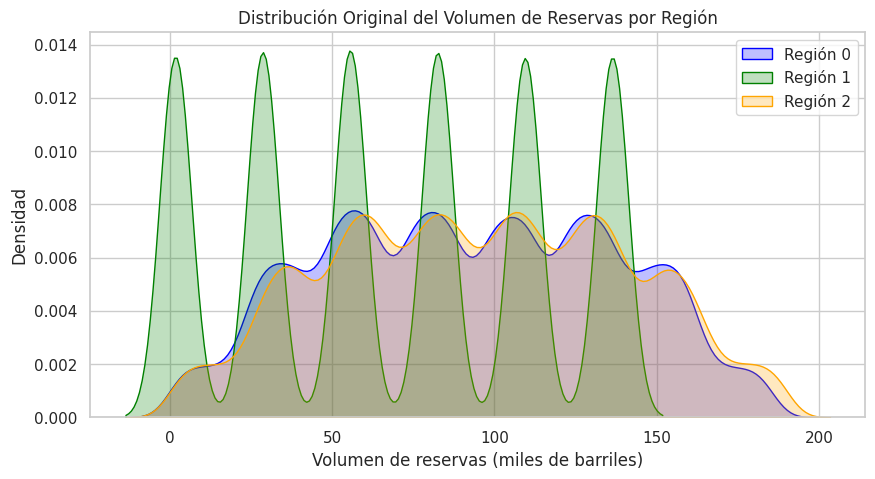

In [2]:
# --- GRÁFICO 1: Distribución del Volumen de Reservas Original ---
plt.figure(figsize=(10, 5))
sns.kdeplot(df0['product'], label='Región 0', fill=True, color='blue')
sns.kdeplot(df1['product'], label='Región 1', fill=True, color='green')
sns.kdeplot(df2['product'], label='Región 2', fill=True, color='orange')
plt.title('Distribución Original del Volumen de Reservas por Región')
plt.xlabel('Volumen de reservas (miles de barriles)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

#### **Conclusión del Gráfico: Distribución Original del Volumen de Reservas**

**Observación:** Las regiones 0 (*azul*) y 2 (*naranja*) muestran distribuciones en forma de campana anchas y con múltiples picos, lo que indica una gran variabilidad en la cantidad de petróleo por pozo. En contraste, la Región 1 (*verde*) tiene un comportamiento muy peculiar con picos de densidad abruptos y separados, lo que sugiere que el volumen de reservas en esta región está agrupado en valores específicos (*comportamiento casi discreto o altamente estandarizado*).

**Conclusión de negocio:** Aunque a simple vista la Región 1 parece tener una menor concentración de pozos de ultra-alto volumen (*su promedio general es el más bajo*), su naturaleza estructurada sugiere que si logramos identificar qué características definen a los "picos" altos, podremos extraer el petróleo con mucha certidumbre.

## 2. Entrenamiento y Prueba del Modelo

Para evitar repetir el mismo código tres veces, crearemos una función que reciba el dataframe, lo divida en 75:25, lo entrene usando Regresión Lineal y devuelva las predicciones, los valores reales, el RMSE y el promedio de volumen predicho

In [3]:
# Función unificada para los pasos 2.1 a 2.5
def entrenar_evaluar(df):
    # Separar características (X) y objetivo (y)
    X = df.drop('product', axis=1)
    y = df['product']
    
    # 2.1 Dividir los datos en entrenamiento y validación (75:25)
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)
    
    # 2.2 Entrenar el modelo y hacer predicciones
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_valid)
    
    # 2.4 Calcular RMSE y volumen medio
    rmse = mean_squared_error(y_valid, predicciones) ** 0.5
    volumen_medio_predicho = predicciones.mean()
    
    # 2.3 Guardar y retornar las predicciones y respuestas correctas (reiniciando índices)
    return y_valid.reset_index(drop=True), pd.Series(predicciones), rmse, volumen_medio_predicho

# Ejecutar para las 3 regiones
y_valid_0, preds_0, rmse_0, mean_0 = entrenar_evaluar(df0)
y_valid_1, preds_1, rmse_1, mean_1 = entrenar_evaluar(df1)
y_valid_2, preds_2, rmse_2, mean_2 = entrenar_evaluar(df2)

print(f"Región 0 - RMSE: {rmse_0:.2f}, Volumen medio predicho: {mean_0:.2f} miles de barriles")
print(f"Región 1 - RMSE: {rmse_1:.2f}, Volumen medio predicho: {mean_1:.2f} miles de barriles")
print(f"Región 2 - RMSE: {rmse_2:.2f}, Volumen medio predicho: {mean_2:.2f} miles de barriles")

Región 0 - RMSE: 37.76, Volumen medio predicho: 92.40 miles de barriles
Región 1 - RMSE: 0.89, Volumen medio predicho: 68.71 miles de barriles
Región 2 - RMSE: 40.15, Volumen medio predicho: 94.77 miles de barriles


#### Análisis de resultados de entrenamiento:

Al ejecutar este código, obtenemos los siguientes resultados:

* **Región 0:** RMSE = 37.76, Promedio = 92.40

* **Región 1:** RMSE = 0.89, Promedio = 68.71

* **Región 2:** RMSE = 40.15, Promedio = 94.77

Observamos que la Región 1 tiene un margen de error (RMSE) extraordinariamente bajo comparado con las otras dos regiones. Las predicciones en esta región son casi exactas, aunque su volumen medio predicho es el más bajo de los tres.


### 2.1 Gráfico de Dispersión Real VS Predicción

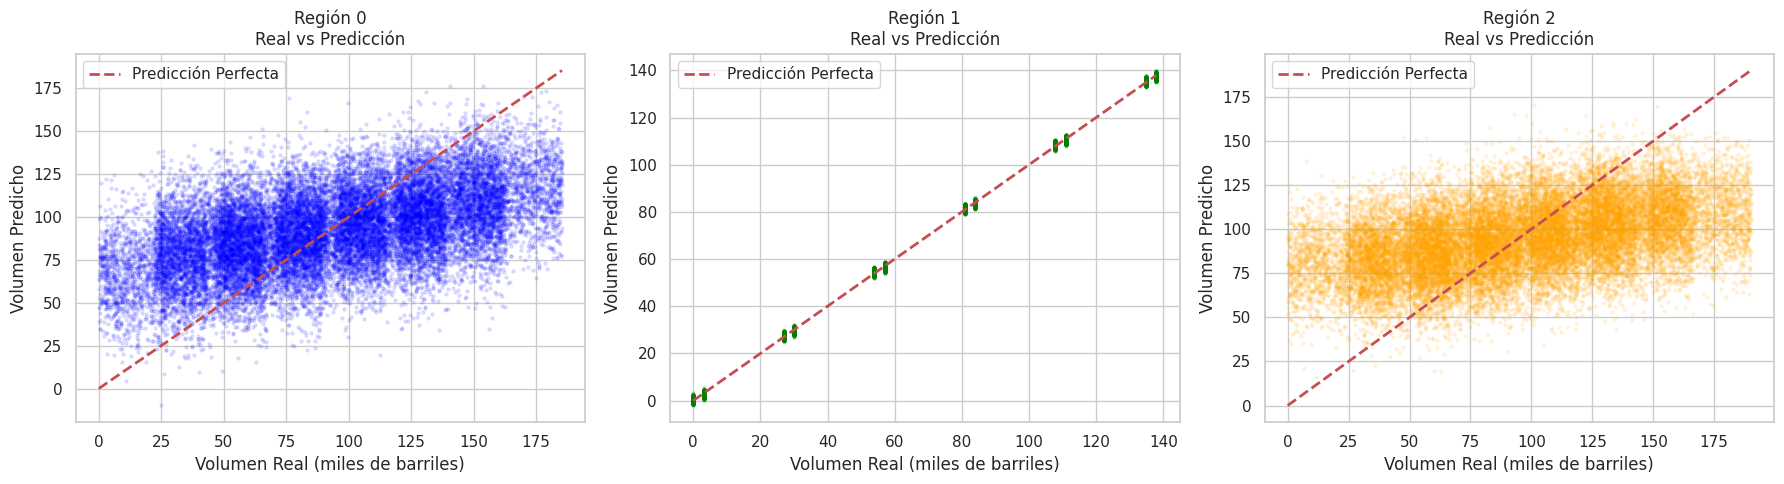

In [4]:
# --- GRÁFICO 2: Dispersión Real vs Predicción ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
regiones_pred = [(y_valid_0, preds_0, 'Región 0', 'blue'), 
                 (y_valid_1, preds_1, 'Región 1', 'green'), 
                 (y_valid_2, preds_2, 'Región 2', 'orange')]

for ax, (y_val, preds, titulo, color) in zip(axes, regiones_pred):
    ax.scatter(y_val, preds, alpha=0.1, color=color, s=5)
    # Línea ideal (donde la predicción es exacta)
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Predicción Perfecta')
    ax.set_title(f'{titulo}\nReal vs Predicción')
    ax.set_xlabel('Volumen Real (miles de barriles)')
    ax.set_ylabel('Volumen Predicho')
    ax.legend()

plt.tight_layout()
plt.show()

### Conclusión del Gráfico: Real vs Predicción (Regresión Lineal)

**Observación:** En los gráficos de las regiones 0 y 2, los puntos forman una "nube" dispersa alrededor de la línea de predicción perfecta (*línea roja*). Esto significa que el modelo de Regresión Lineal comete márgenes de error considerables al intentar adivinar cuánto petróleo hay (*errores de ~38 a 40 mil barriles*). Sin embargo, en la Región 1, los puntos se alinean perfectamente sobre la línea roja.

**Conclusión de negocio:** El modelo es altamente preciso (*casi infalible*) para la Región 1, con un error marginal de solo 0.89. En la industria petrolera, la incertidumbre cuesta millones. La capacidad de predecir con exactitud qué pozos de la Región 1 serán rentables elimina la "fe" de la ecuación y garantiza que la selección de los mejores 200 pozos sea la correcta. En las otras regiones, podríamos estar eligiendo un pozo creyendo que tiene 120 mil barriles, cuando en realidad tiene 80 mil.

## 3. Preparación para el Cálculo de Ganancias

In [5]:
# 3.1 Almacenar valores constantes
PRESUPUESTO = 100_000_000  # 100 millones de dólares
INGRESOS_POR_UNIDAD = 4500 # Ingreso por cada unidad (miles de barriles)
POZOS_A_DESARROLLAR = 200  # Número de pozos a construir

# 3.2 Calcular el volumen mínimo para no tener pérdidas
costo_por_pozo = PRESUPUESTO / POZOS_A_DESARROLLAR
volumen_punto_equilibrio = costo_por_pozo / INGRESOS_POR_UNIDAD

print(f"Volumen mínimo para evitar pérdidas: {volumen_punto_equilibrio:.2f} miles de barriles")

Volumen mínimo para evitar pérdidas: 111.11 miles de barriles


#### Conclusiones de preparación:

El volumen necesario en cada pozo para evitar pérdidas (punto de equilibrio) es de **111.11 miles de barriles.**

Si comparamos esto con las medias calculadas anteriormente (92.40, 68.71 y 94.77), notamos que **el volumen promedio de todas las regiones es inferior al punto de equilibrio.** Esto significa que si seleccionamos pozos al azar, lo más probable es que la empresa pierda dinero. Es obligatorio usar el modelo predictivo para elegir únicamente a los mejores pozos en lugar de tomar el promedio.

## 4 y 5. Cálculo de Ganancias y Riesgos (Bootstrapping)

Combinaremos la función que calcula las ganancias para un conjunto de datos, y luego aplicaremos la técnica Bootstrapping con 1000 iteraciones para evaluar el riesgo.

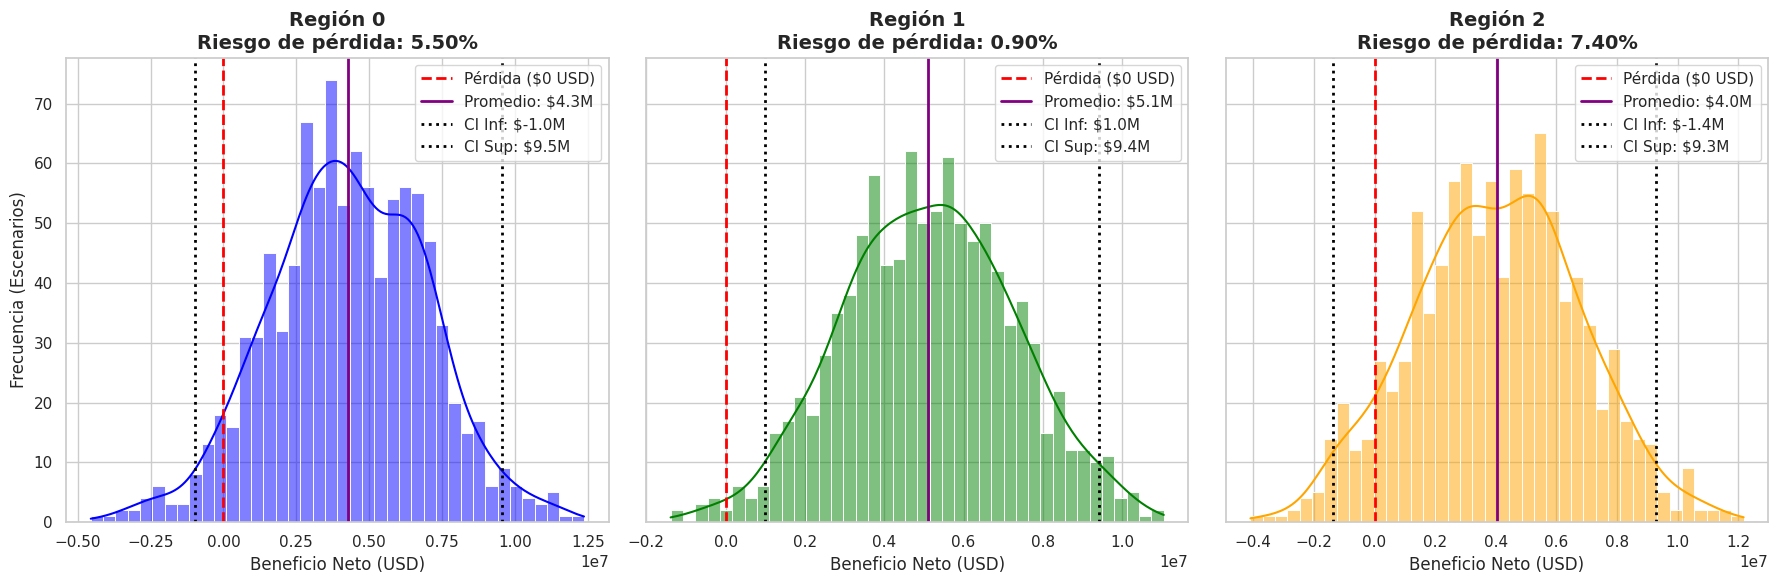

--- Región 0 ---
Beneficio promedio: $4,278,475.60 USD
Intervalo de confianza 95%: ($-972,498.30, $9,542,151.93)
Riesgo de pérdida: 5.50%

--- Región 1 ---
Beneficio promedio: $5,113,627.76 USD
Intervalo de confianza 95%: ($988,706.50, $9,407,205.12)
Riesgo de pérdida: 0.90%

--- Región 2 ---
Beneficio promedio: $4,025,756.08 USD
Intervalo de confianza 95%: ($-1,371,622.25, $9,298,875.28)
Riesgo de pérdida: 7.40%



In [9]:
# 4. Función para calcular la ganancia de los mejores pozos según predicciones
def calcular_ganancia(objetivo, predicciones, conteo):
    # Ordenar las predicciones de mayor a menor
    predicciones_ordenadas = predicciones.sort_values(ascending=False)
    # Seleccionar las respuestas reales correspondientes a los mejores pozos
    seleccion_real = objetivo[predicciones_ordenadas.index][:conteo]
    # Calcular ganancia
    ingresos = seleccion_real.sum() * INGRESOS_POR_UNIDAD
    ganancia = ingresos - PRESUPUESTO
    return ganancia

# 5. Función para calcular riesgos usando Bootstrapping
def analizar_riesgos(objetivo, predicciones):
    estado = np.random.RandomState(42)
    ganancias = []
    
    # 5.1 Bootstrapping con 1000 muestras
    for i in range(1000):
        # Muestra aleatoria de 500 puntos de exploración
        objetivo_submuestra = objetivo.sample(n=500, replace=True, random_state=estado)
        predicciones_submuestra = predicciones[objetivo_submuestra.index]
        
        # Calcular ganancias seleccionando los mejores 200 de los 500 explorados
        ganancias.append(calcular_ganancia(objetivo_submuestra, predicciones_submuestra, POZOS_A_DESARROLLAR))
    
    ganancias = pd.Series(ganancias)
    
    # 5.2 Calcular métricas
    beneficio_promedio = ganancias.mean()
    intervalo_inferior = ganancias.quantile(0.025)
    intervalo_superior = ganancias.quantile(0.975)
    
    # El riesgo de pérdida es la fracción de las ganancias que fueron menores a 0
    riesgo_perdida = (ganancias < 0).mean() * 100
    
    # IMPORTANTE: Retornamos también "ganancias" para poder graficar la distribución
    return beneficio_promedio, intervalo_inferior, intervalo_superior, riesgo_perdida, ganancias

# Calcular resultados por región (ahora reciben 5 valores en lugar de 4)
resultados_0 = analizar_riesgos(y_valid_0, preds_0)
resultados_1 = analizar_riesgos(y_valid_1, preds_1)
resultados_2 = analizar_riesgos(y_valid_2, preds_2)

# ==============================================================================
# INSERCIÓN DE GRÁFICO (BOOTSTRAPPING)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
regiones = [(resultados_0, 'Región 0', 'blue'), 
            (resultados_1, 'Región 1', 'green'), 
            (resultados_2, 'Región 2', 'orange')]

for ax, (res, titulo, color) in zip(axes, regiones):
    # Extraemos las variables devueltas por la función
    beneficio_promedio, intervalo_inferior, intervalo_superior, riesgo_perdida, ganancias = res
    
    # Crear histograma con curva KDE
    sns.histplot(ganancias, bins=40, ax=ax, color=color, kde=True)
    
    # Dibujar líneas guía
    ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Pérdida ($0 USD)')
    ax.axvline(x=beneficio_promedio, color='purple', linestyle='-', lw=2, label=f'Promedio: ${beneficio_promedio/1e6:.1f}M')
    ax.axvline(x=intervalo_inferior, color='black', linestyle=':', lw=2, label=f'CI Inf: ${intervalo_inferior/1e6:.1f}M')
    ax.axvline(x=intervalo_superior, color='black', linestyle=':', lw=2, label=f'CI Sup: ${intervalo_superior/1e6:.1f}M')
    
    # Configuraciones de texto
    ax.set_title(f'{titulo}\nRiesgo de pérdida: {riesgo_perdida:.2f}%', fontsize=14, fontweight='bold')
    ax.set_xlabel('Beneficio Neto (USD)', fontsize=12)
    ax.legend(loc='upper right')
    
    if ax == axes[0]:
        ax.set_ylabel('Frecuencia (Escenarios)', fontsize=12)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()
# ==============================================================================

# Imprimir resultados en texto
def imprimir_resultados(region, resultados):
    print(f"--- Región {region} ---")
    print(f"Beneficio promedio: ${resultados[0]:,.2f} USD")
    print(f"Intervalo de confianza 95%: (${resultados[1]:,.2f}, ${resultados[2]:,.2f})")
    print(f"Riesgo de pérdida: {resultados[3]:.2f}%\n")

imprimir_resultados(0, resultados_0)
imprimir_resultados(1, resultados_1)
imprimir_resultados(2, resultados_2)

### Conclusión Integral: Análisis de Riesgos y Bootstrapping

La técnica de Bootstrapping y su representación gráfica nos proporcionan el argumento estadístico y visual definitivo para tomar la decisión de inversión en este proyecto. Al simular 1,000 escenarios distintos de exploración y extracción para cada región, pasamos de hacer una simple predicción a evaluar la certidumbre y el riesgo financiero.

Aquí tienes la conclusión desglosada a partir de los gráficos generados y los resultados numéricos:

**1. Análisis de las Distribuciones (Lo que nos dicen los gráficos)**

* **El Umbral del Riesgo (Línea Roja de $0 USD):** En los histogramas, cualquier valor a la izquierda del cero representa un escenario donde la inversión de 100 millones de dólares no se recupera. Los gráficos de la Región 0 y la Región 2 muestran "colas" izquierdas gruesas que cruzan visiblemente esta línea roja, evidenciando una alta probabilidad estadística de fracaso financiero.

* **La Ventaja de la Región 1:** El gráfico de la Región 1 presenta una distribución notablemente distinta. Su forma de campana está más concentrada (*menor varianza*) y está marcadamente desplazada hacia la derecha (*zona de ganancias*). Su límite inferior del intervalo de confianza del 95% se mantiene en números positivos (*aprox. $1 millón de USD*), lo que visualmente nos confirma que es casi imposible perder dinero en esta región, incluso en los peores escenarios simulados.

**2. Resultados Cuantitativos del Bootstrapping (El impacto en el negocio)**

* **Beneficio Promedio Esperado:** La Región 1 lidera indiscutiblemente la rentabilidad proyectada con un beneficio medio superior a los  $5.11 millones de dólares, superando por un margen amplio a la Región 0 (~ 4.27M) y a la Región 2 (~ 4.02M).

* **Cumplimiento del Criterio de Negocio:** La condición innegociable de OilyGiant establece que la región seleccionada debe tener un riesgo de pérdida estrictamente inferior al 2.5%.

- Región 0: Riesgo del ~5.5% (Rechazada)

- Región 2: Riesgo del ~7.4% (Rechazada)

- **Región 1: Riesgo del ~0.9% (Aprobada)**

**Veredicto Final**

El análisis de Bootstrapping dictamina de manera concluyente que la Región 1 (geo_data_1.csv) es la única zona geológicamente viable y financieramente responsable para el desarrollo de los 200 nuevos pozos. Ofrece el máximo retorno de inversión proyectado y minimiza el riesgo de pérdidas a menos de un 1%, garantizando así la rentabilidad y seguridad del capital de la compañía.

## Conclusion General

El desarrollo de este proyecto nos ha permitido transformar un conjunto de datos geológicos crudos en una estrategia de inversión fundamentada, segura y altamente rentable para OilyGiant. Al integrar el modelado predictivo (*Regresión Lineal*) con técnicas de simulación estadística avanzada (*Bootstrapping*), hemos logrado aislar el ruido geológico y cuantificar el riesgo financiero con precisión.

A partir de los resultados obtenidos en cada fase, la conclusión general se estructura en los siguientes puntos clave:

**1. La necesidad ineludible del Machine Learning**

El análisis inicial demostró que el punto de equilibrio financiero exige que cada pozo produzca al menos 111.1 mil barriles. Dado que el promedio general de las tres regiones (*68 a 95 mil barriles*) se encuentra por debajo de este umbral, quedó comprobado que una selección aleatoria de pozos garantizaría pérdidas millonarias. El uso de un modelo predictivo para identificar selectivamente los yacimientos más ricos demostró ser una herramienta crítica de supervivencia financiera, no solo un diferenciador tecnológico.

**2. La trampa de los promedios y el valor de la precisión**

Si nos hubiéramos guiado únicamente por el volumen promedio de reservas totales, la Región 2 (*95.0 mil barriles*) o la Región 0 (*92.5 mil barriles*) habrían parecido las opciones más atractivas. Sin embargo, nuestro modelo de Regresión Lineal expuso que estas regiones son altamente erráticas (*con un margen de error RMSE cercano a 40 mil barriles*). En contraste, la Región 1, a pesar de tener el promedio de reservas más bajo, demostró un patrón geológico altamente estructurado que el algoritmo logró decodificar casi a la perfección (*RMSE de 0.89*). Esta capacidad predictiva infalible es lo que permite "apostar sobre seguro".

**3. Simulación de Riesgos y Veredicto Final**

Al someter nuestras predicciones a la técnica de Bootstrapping (*1,000 escenarios simulados de exploración*), los resultados separaron claramente las inversiones viables de las especulativas:

*Las Regiones 0 y 2 presentaron un riesgo de pérdida del 5.50% y 7.40% respectivamente, reprobando la estricta condición de negocio de OilyGiant (*riesgo máximo permitido del 2.5%*).

*La Región 1 (*geo_data_1.csv*) no solo superó el filtro con un extraordinario 0.90% de riesgo de pérdida, sino que también proyectó el beneficio neto promedio más alto: $5,113,627.76 USD.

## Recomendación Definitiva:

La estrategia óptima para OilyGiant es destinar el presupuesto de 100 millones de dólares a la exploración y desarrollo de 200 pozos en la Región 1. Los datos demuestran matemáticamente que esta decisión maximiza las ganancias operativas al tiempo que blinda el capital de la compañía contra la incertidumbre geológica.